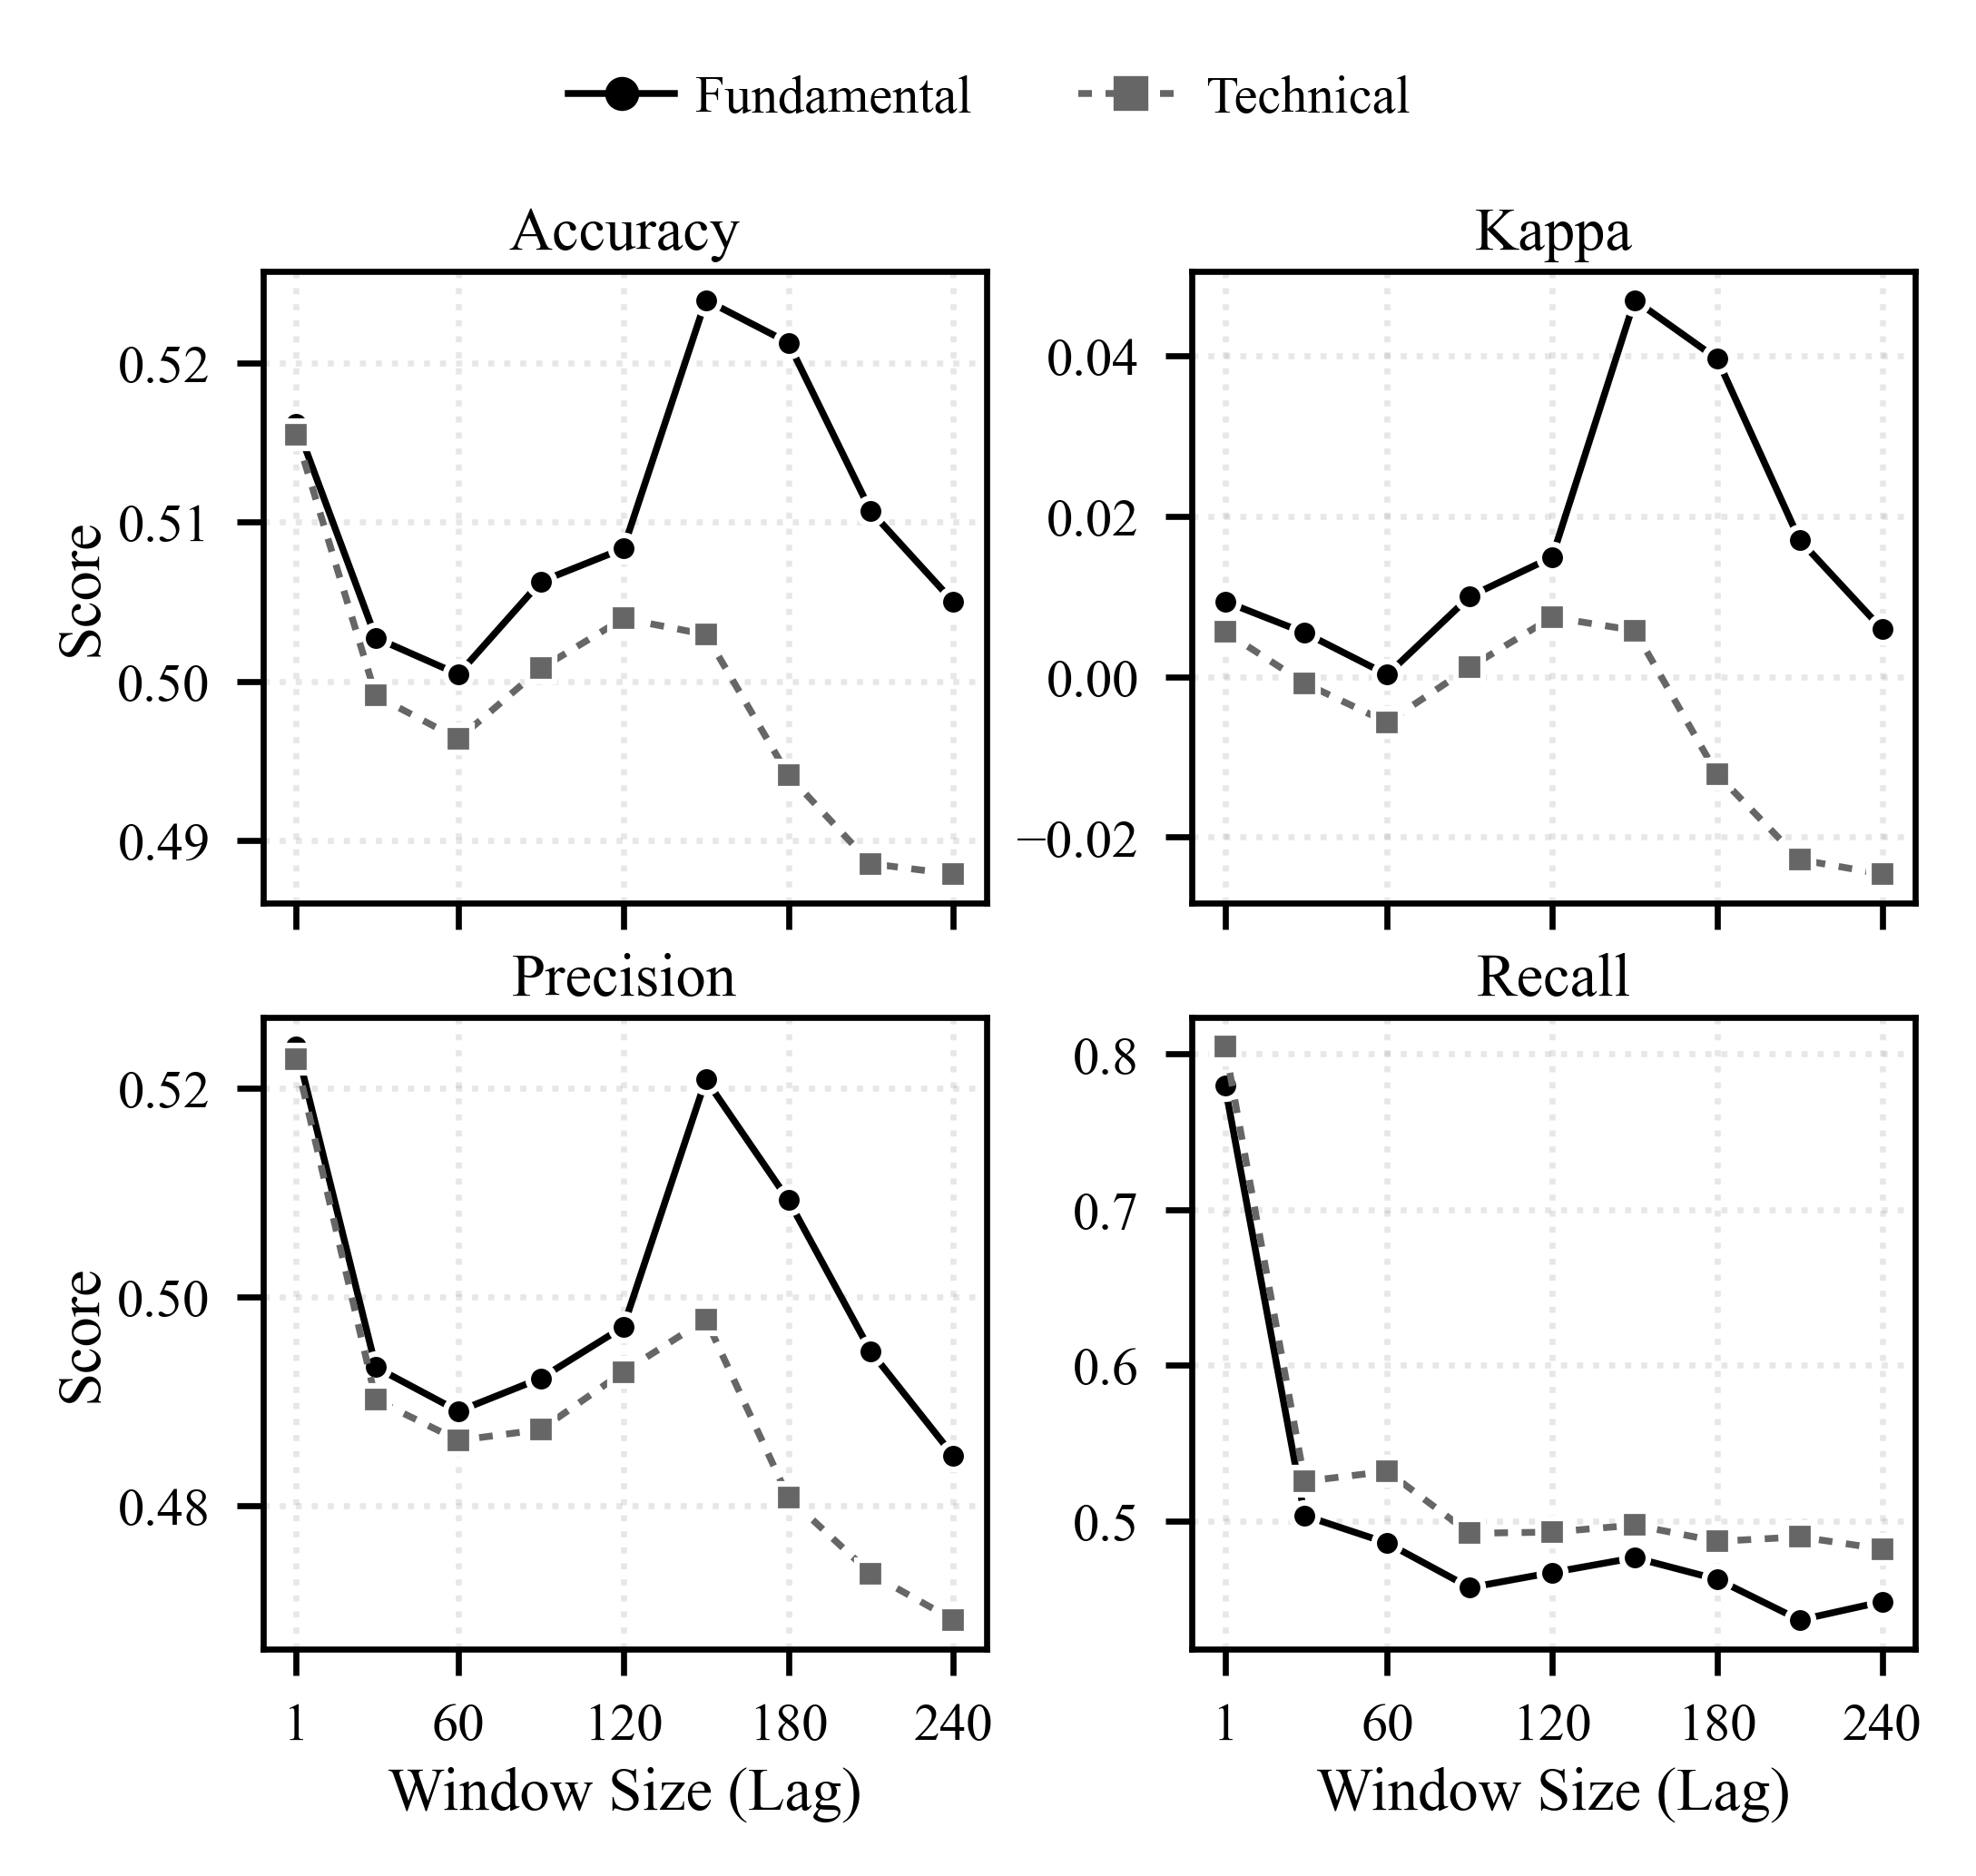

[INFO] Saved IEEE standard (3.5in): figures/global_metrics_delay_1.pdf

GLOBAL DATA TABLE (DELAY 1) - MICRO-AVERAGE
 lag       Domain  Accuracy   Kappa  Precision  Recall
   1  Fundamental    0.5162  0.0094     0.5240  0.7796
   1    Technical    0.5155  0.0056     0.5228  0.8052
  30  Fundamental    0.5027  0.0055     0.4933  0.5034
  30    Technical    0.4991 -0.0008     0.4901  0.5255
  60  Fundamental    0.5004  0.0003     0.4890  0.4859
  60    Technical    0.4964 -0.0057     0.4862  0.5319
  90  Fundamental    0.5063  0.0100     0.4922  0.4572
  90    Technical    0.5008  0.0012     0.4873  0.4921
 120  Fundamental    0.5083  0.0149     0.4971  0.4669
 120    Technical    0.5039  0.0074     0.4928  0.4929
 150  Fundamental    0.5239  0.0469     0.5208  0.4764
 150    Technical    0.5029  0.0058     0.4978  0.4973
 180  Fundamental    0.5213  0.0396     0.5093  0.4625
 180    Technical    0.4941 -0.0122     0.4808  0.4869
 210  Fundamental    0.5107  0.0170     0.4947  0.4364
 210

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.font_manager as fm
import numpy as np

# ==============================================================================
# 1. FONT LOADING (TIMES NEW ROMAN)
# ==============================================================================
possible_paths = [
    os.path.expanduser('~/.local/share/fonts/times.ttf'),
    os.path.expanduser('~/.local/share/fonts/Times New Roman.ttf'),
    '/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf',
    'C:/Windows/Fonts/times.ttf'
]

font_path = None
for p in possible_paths:
    if os.path.exists(p):
        font_path = p
        break

try:
    if font_path:
        fm.fontManager.addfont(font_path)
        font_prop = fm.FontProperties(fname=font_path)
        exact_font_name = font_prop.get_name()
    else:
        exact_font_name = 'serif'
except Exception:
    exact_font_name = 'serif'

# ==============================================================================
# 2. DATA (Loading and Filtering)
# ==============================================================================
selected_delay = 1
expected_lags = [1, 30, 60, 90, 120, 150, 180, 210, 240]

file_path = f'results/results_HT_delay_{selected_delay}.csv'

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    
    # Asset filter (2023 Liquidity)
    try:
        df_stock = pd.read_csv('/home/jjos/profit_performance/valor_mobiliario.csv')
        if not pd.api.types.is_datetime64_any_dtype(df_stock['Data_Referencia']):
            df_stock['Data_Referencia'] = pd.to_datetime(df_stock['Data_Referencia'], errors='coerce')

        valid_tickers = df_stock[df_stock['Data_Referencia'].dt.year == 2023].Codigo_Negociacao.unique()
        df = df[df['dataset'].isin(valid_tickers)]
        df = df[~df['dataset'].isin(['LEVE3'])] # Explicit exclusion
    except Exception as e:
        print(f"[WARNING] Asset filtering failed ({e}). Using all assets.")

    # Standardize lag column name if it still comes as fh
    if 'fh' in df.columns: 
        df.rename(columns={'fh': 'lag'}, inplace=True)
    
    domain_map = {'fund': 'Fundamental', 'nao_fund': 'Technical'}
    df['Domain'] = df['category'].map(domain_map)
    
    # Global Grouping (Micro-Average)
    df_grouped = df.groupby(['lag', 'Domain'])[['TP', 'TN', 'FP', 'FN']].sum().reset_index()
    
    total = df_grouped['TP'] + df_grouped['TN'] + df_grouped['FP'] + df_grouped['FN']
    df_grouped['Accuracy'] = (df_grouped['TP'] + df_grouped['TN']) / total
    
    # Precision & Recall
    df_grouped['Precision'] = df_grouped['TP'] / (df_grouped['TP'] + df_grouped['FP'])
    df_grouped['Recall'] = df_grouped['TP'] / (df_grouped['TP'] + df_grouped['FN'])
    
    # Kappa
    po = df_grouped['Accuracy']
    pe_pos = ((df_grouped['TP'] + df_grouped['FP']) * (df_grouped['TP'] + df_grouped['FN'])) / (total**2)
    pe_neg = ((df_grouped['TN'] + df_grouped['FN']) * (df_grouped['TN'] + df_grouped['FP'])) / (total**2)
    df_grouped['Kappa'] = (po - (pe_pos + pe_neg)) / (1 - (pe_pos + pe_neg))
    
    df_global = df_grouped.copy()
else:
    print("[WARNING] File not found. Generating empty DataFrame.")
    df_global = pd.DataFrame() 

# ==============================================================================
# 3. IEEE CONFIGURATION (1 COLUMN STANDARD = 3.5 inches)
# ==============================================================================
IEEE_COL_WIDTH = 3.5  
IEEE_HEIGHT = 3.2     

plt.rcParams.update({
    'font.family': exact_font_name,
    'font.size': 8,              
    'axes.labelsize': 8,         
    'axes.titlesize': 9,         
    'legend.fontsize': 7,        
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'figure.dpi': 600,
    'lines.linewidth': 0.9,      
    'lines.markersize': 3.5,       
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': ':'
})

metrics_to_plot = {
    'Accuracy': 'Accuracy', 'Kappa': 'Kappa',
    'Precision': 'Precision', 'Recall': 'Recall'
}
palette = {'Fundamental': 'black', 'Technical': '#666666'}
markers = {'Fundamental': 'o', 'Technical': 's'}
dashes = {'Fundamental': (None, None), 'Technical': (2, 2)}

# ==============================================================================
# 4. PLOTTING
# ==============================================================================
if not df_global.empty:
    fig, axes = plt.subplots(2, 2, figsize=(IEEE_COL_WIDTH, IEEE_HEIGHT), sharex=True)
    axes = axes.flatten()

    handles, labels = [], []

    for i, (metric, title) in enumerate(metrics_to_plot.items()):
        ax = axes[i]
        if metric in df_global.columns:
            sns.lineplot(data=df_global, x='lag', y=metric, hue='Domain', style='Domain',
                         palette=palette, markers=markers, dashes=dashes, ax=ax, legend=True)
            
            # Capture legend handles only once
            if i == 0: 
                handles, labels = ax.get_legend_handles_labels()
            if ax.get_legend(): 
                ax.get_legend().remove()
        
        ax.set_title(title, fontweight='normal', pad=3, fontsize=8)
        
        # Y Label only on the left to save space
        if i % 2 == 0: 
            ax.set_ylabel('Score', labelpad=1) 
        else: 
            ax.set_ylabel('') 

        # X-axis ticks adjustment
        ax.set_xticks([1, 60, 120, 180, 240])

    # X Labels at the bottom
    axes[2].set_xlabel('Window Size (Lag)', labelpad=2)
    axes[3].set_xlabel('Window Size (Lag)', labelpad=2)

    # Top legend
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.04), 
               ncol=2, frameon=False, fontsize=7, handletextpad=0.4)

    plt.tight_layout(pad=0.3, w_pad=0.5, h_pad=0.5) 
    plt.subplots_adjust(top=0.90) 

    os.makedirs('figures', exist_ok=True)
    output_filename = f'figures/global_metrics_delay_{selected_delay}.pdf'
    plt.savefig(output_filename, format='pdf', dpi=600, bbox_inches='tight')
    plt.show()
    print(f"[INFO] Saved IEEE standard (3.5in): {output_filename}")

# ==============================================================================
# 5. DATA TABLE EXTRACTION
# ==============================================================================
print("\n" + "="*80)
print(f"GLOBAL DATA TABLE (DELAY {selected_delay}) - MICRO-AVERAGE")
print("="*80)

if not df_global.empty:
    # 1. Select relevant columns
    cols_final = ['lag', 'Domain', 'Accuracy', 'Kappa', 'Precision', 'Recall']
    df_final = df_global[cols_final].sort_values(by=['lag', 'Domain'])

    # 2. Configure pandas display
    pd.set_option('display.max_rows', None)
    pd.set_option('display.width', 1000)
    pd.set_option('display.float_format', '{:.4f}'.format)

    # 3. Print flat table
    print(df_final.to_string(index=False))

    print("\n" + "="*80)
    print("COMPARATIVE TABLE (SIDE-BY-SIDE - ACCURACY AND KAPPA)")
    print("="*80)

    # 4. Pivoted version (Better to compare Fundamental vs Technical)
    df_pivot = df_global.pivot(index='lag', columns='Domain', values=['Accuracy', 'Kappa'])
    print(df_pivot)
else:
    print("[WARNING] No data available for the table.")